In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch
from torchinfo import summary
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import _LRScheduler
import torch.utils.data as data
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn import decomposition
from sklearn import manifold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import numpy as np
import copy
import random
import time
from torch.utils.data import Dataset, DataLoader, random_split
import os
import seaborn as sns


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gourangamaitymca/kmc-renal-liver-dataset-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/gourangamaitymca/kmc-renal-liver-dataset-classification


In [4]:
import torch
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader

In [5]:
BATCH_SIZE=16
IMG_SIZE=224

In [7]:
train_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

val_test_transform=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [8]:
train_dataset=datasets.ImageFolder(
    root="/kaggle/input/datasets/gourangamaitymca/kmc-renal-liver-dataset-classification/TCGA-KIDNEY-FINAL/Data/Training",
    transform=train_transform
)

val_dataset=datasets.ImageFolder(
    root="/kaggle/input/datasets/gourangamaitymca/kmc-renal-liver-dataset-classification/TCGA-KIDNEY-FINAL/Data/Validation",
    transform=val_test_transform
)
test_dataset=datasets.ImageFolder(
    root="/kaggle/input/datasets/gourangamaitymca/kmc-renal-liver-dataset-classification/TCGA-KIDNEY-FINAL/Data/Test",
    transform=val_test_transform
)

In [10]:
train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)
val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)
test_loader=DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

In [11]:
print("Classes:", train_dataset.classes)
print("Number of classes:", len(train_dataset.classes))

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))


Classes: ['KICH', 'KIRC', 'KIRP', 'Normal']
Number of classes: 4
Train size: 3621
Validation size: 632
Test size: 632


In [12]:
images,labels=next(iter(train_loader))

print(images.size())
print(labels.size())

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [13]:
import torch.nn as nn

class CBAM(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.maxpool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels//reduction),
            nn.ReLU(),
            nn.Linear(channels//reduction, channels)
        )

        self.sigmoid = nn.Sigmoid()

        self.conv = nn.Conv2d(2,1,7,padding=3)

    def forward(self, x):

        b,c,h,w = x.shape

        avg = self.fc(self.avgpool(x).view(b,c))
        max = self.fc(self.maxpool(x).view(b,c))

        ca = self.sigmoid(avg+max).view(b,c,1,1)

        x = x * ca

        avg = torch.mean(x,dim=1,keepdim=True)
        max,_ = torch.max(x,dim=1,keepdim=True)

        sa = self.sigmoid(self.conv(torch.cat([avg,max],dim=1)))

        return x * sa


In [14]:
class SE(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels//reduction),
            nn.ReLU(),
            nn.Linear(channels//reduction, channels),
            nn.Sigmoid()
        )

    def forward(self,x):

        b,c,_,_ = x.shape

        y = self.pool(x).view(b,c)

        y = self.fc(y).view(b,c,1,1)

        return x*y


In [16]:
class MHA(nn.Module):

    def __init__(self, channels, heads=8):
        super().__init__()

        self.mha = nn.MultiheadAttention(
    embed_dim=2048,
    num_heads=8,
    batch_first=True
)

    def forward(self,x):

        b,c,h,w = x.shape

        x = x.view(b,c,-1).permute(0,2,1)

        x,_ = self.mha(x,x,x)

        x = x.permute(0,2,1).view(b,c,h,w)

        return x


In [17]:
class TrueResNet50Fusion(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        resnet = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )

        # Freeze backbone
        for param in resnet.parameters():
            param.requires_grad = False

        self.layers = nn.ModuleList()

        self.layers.append(resnet.conv1)
        self.layers.append(resnet.bn1)
        self.layers.append(resnet.relu)
        self.layers.append(resnet.maxpool)

        for block in resnet.layer1:
            self.layers.append(block)

        for block in resnet.layer2:
            self.layers.append(block)

        for block in resnet.layer3:
            self.layers.append(block)

        for block in resnet.layer4:
            self.layers.append(block)

        self.cbam = CBAM(64)
        self.se   = SE(512)
        self.mha  = MHA(2048)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(

            nn.Linear(64+512+2048,1024),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(1024,num_classes)
        )


    def forward(self,x):

        layer_counter=0

        cbam_out=None
        se_out=None
        mha_out=None

        for layer in self.layers:

            x=layer(x)

            layer_counter+=1

            if layer_counter==3:

                cbam_feat=self.cbam(x)

                cbam_out=self.pool(cbam_feat).flatten(1)

            if layer_counter==8:

                se_feat=self.se(x)

                se_out=self.pool(se_feat).flatten(1)

            if layer_counter == len(self.layers):

                mha_feat = self.mha(x)

                mha_out = self.pool(mha_feat).flatten(1)

        fused=torch.cat([cbam_out,se_out,mha_out],dim=1)

        out=self.classifier(fused)

        return out


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [19]:
Targets=np.array(train_dataset.targets)
indices=np.arange(len(Targets))

In [12]:
Targets

array([0, 0, 0, ..., 3, 3, 3])

In [20]:
from sklearn.utils.class_weight import compute_class_weight

In [21]:
classes = np.unique(Targets)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=Targets
)

class_weights = torch.tensor(weights, dtype=torch.float).cuda()



In [22]:
num_classes=len(np.unique(Targets))

In [24]:
print(num_classes)

4


In [23]:
model = TrueResNet50Fusion(num_classes).to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]


In [24]:
summary(model, input_size=(16 ,3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
TrueResNet50Fusion                       [16, 4]                   --
├─ModuleList: 1-7                        --                        (recursive)
│    └─Conv2d: 2-1                       [16, 64, 112, 112]        (9,408)
│    └─BatchNorm2d: 2-2                  [16, 64, 112, 112]        (128)
│    └─ReLU: 2-3                         [16, 64, 112, 112]        --
├─CBAM: 1-2                              [16, 64, 112, 112]        --
│    └─AdaptiveAvgPool2d: 2-4            [16, 64, 1, 1]            --
│    └─Sequential: 2-5                   [16, 64]                  --
│    │    └─Linear: 3-1                  [16, 4]                   260
│    │    └─ReLU: 3-2                    [16, 4]                   --
│    │    └─Linear: 3-3                  [16, 64]                  320
│    └─AdaptiveMaxPool2d: 2-6            [16, 64, 1, 1]            --
│    └─Sequential: 2-7                   [16, 64]                 

In [ ]:
model = TrueResNet50Fusion(num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

In [25]:
optimizer = optim.Adam(model.parameters(), lr= 0.0001, weight_decay=1e-5)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3
)

In [26]:
weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)

In [27]:
criterion=nn.CrossEntropyLoss(weight=weights_tensor)

In [28]:
def compute_specificity(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    if len(cm) == 2:  # binary
        TN, FP, FN, TP = cm.ravel()
        specificity = TN / (TN + FP + 1e-8)

    else:  # multiclass
        specificity_per_class = []

        for i in range(len(cm)):

            TN = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
            FP = cm[:,i].sum() - cm[i,i]

            specificity_per_class.append(TN/(TN+FP+1e-8))

        specificity = np.mean(specificity_per_class)

    return specificity


In [30]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0

    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    loss = total_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)

    recall = recall_score(all_labels, all_preds, average="macro")

    f1 = f1_score(all_labels, all_preds, average="macro")

    specificity = compute_specificity(all_labels, all_preds)

    sensitivity = recall  # same thing

    return loss, acc, precision, recall, specificity, sensitivity, f1


In [31]:
def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    loss = total_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)

    recall = recall_score(all_labels, all_preds, average="macro")

    f1 = f1_score(all_labels, all_preds, average="macro")

    specificity = compute_specificity(all_labels, all_preds)

    sensitivity = recall

    return loss, acc, precision, recall, specificity, sensitivity, f1


In [32]:
def train_model(model,
                train_loader,
                val_loader,
                optimizer,
                criterion,
                device,
                epochs):

    history = {

        "train_loss": [],
        "val_loss": [],

        "train_acc": [],
        "val_acc": [],

        "train_precision": [],
        "val_precision": [],

        "train_recall": [],
        "val_recall": [],

        "train_specificity": [],
        "val_specificity": [],

        "train_sensitivity": [],
        "val_sensitivity": [],

        "train_f1": [],
        "val_f1": []
    }

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        train_metrics = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_metrics = validate_one_epoch(
            model, val_loader, criterion, device
        )

        (train_loss, train_acc, train_prec, train_rec,
         train_spec, train_sens, train_f1) = train_metrics

        (val_loss, val_acc, val_prec, val_rec,
         val_spec, val_sens, val_f1) = val_metrics

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        history["train_precision"].append(train_prec)
        history["val_precision"].append(val_prec)

        history["train_recall"].append(train_rec)
        history["val_recall"].append(val_rec)

        history["train_specificity"].append(train_spec)
        history["val_specificity"].append(val_spec)

        history["train_sensitivity"].append(train_sens)
        history["val_sensitivity"].append(val_sens)

        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        print(f"Train Precision: {train_prec:.4f} | Val Precision: {val_prec:.4f}")

        print(f"Train Recall: {train_rec:.4f} | Val Recall: {val_rec:.4f}")

        print(f"Train Specificity: {train_spec:.4f} | Val Specificity: {val_spec:.4f}")

        print(f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

    return history


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [34]:
history = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=20
)


Epoch 1/20
Train Loss: 0.7464 | Val Loss: 0.4860
Train Acc: 0.7067 | Val Acc: 0.8133
Train Precision: 0.7042 | Val Precision: 0.8294
Train Recall: 0.7056 | Val Recall: 0.8133
Train Specificity: 0.9022 | Val Specificity: 0.9378
Train F1: 0.7040 | Val F1: 0.8135

Epoch 2/20
Train Loss: 0.5902 | Val Loss: 0.4531
Train Acc: 0.7802 | Val Acc: 0.8291
Train Precision: 0.7785 | Val Precision: 0.8364
Train Recall: 0.7798 | Val Recall: 0.8291
Train Specificity: 0.9268 | Val Specificity: 0.9430
Train F1: 0.7786 | Val F1: 0.8282

Epoch 3/20
Train Loss: 0.5476 | Val Loss: 0.4444
Train Acc: 0.7912 | Val Acc: 0.8323
Train Precision: 0.7900 | Val Precision: 0.8416
Train Recall: 0.7914 | Val Recall: 0.8323
Train Specificity: 0.9305 | Val Specificity: 0.9441
Train F1: 0.7903 | Val F1: 0.8304

Epoch 4/20
Train Loss: 0.5234 | Val Loss: 0.4541
Train Acc: 0.8039 | Val Acc: 0.8259
Train Precision: 0.8028 | Val Precision: 0.8382
Train Recall: 0.8036 | Val Recall: 0.8259
Train Specificity: 0.9347 | Val Specif

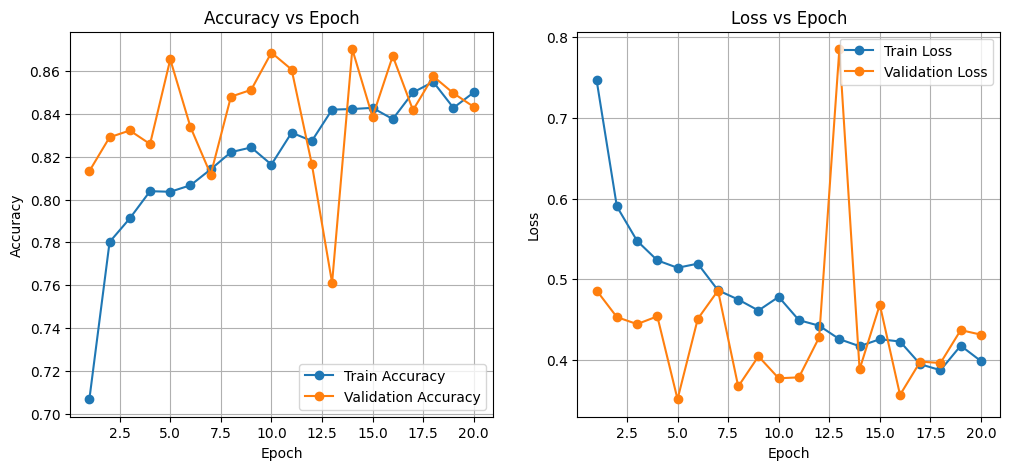

In [37]:
epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epochs, history["train_acc"], marker='o', label="Train Accuracy")
plt.plot(epochs, history["val_acc"], marker='o', label="Validation Accuracy")

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)


# Loss plot
plt.subplot(1,2,2)
plt.plot(epochs, history["train_loss"], marker='o', label="Train Loss")
plt.plot(epochs, history["val_loss"], marker='o', label="Validation Loss")

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()
